In [2]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_df, results_id):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]

        top_ranked = results_df[results_df['rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])


def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)


def compute_best_cases(df_results):

    df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
        df_results['experiment'].apply(extract_exp_info)
    )
     
    # Get max warmup match for each unique config
    idx = df_results.groupby(
        ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
    )['total_final_matches'].idxmax()
    
    df_best_per_config = df_results.loc[idx].reset_index(drop=True)
    
    df_best_per_config['correct_epochs'] = df_best_per_config['total_final_matches'] / 24
    
    df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
    df_best_per_config['target_initial_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-2]
    df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]
    
    df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)
    
    df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)
    
    df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)
    
    # Optional: sort by warmup performance
    df_best_per_config = df_best_per_config[df_best_per_config['similar_districts'] != '']
    df_best_per_config = df_best_per_config.sort_values(by=['total_final_matches', 'max_final_matches', 'similar_districts'], ascending=[False, False, True])

    return df_best_per_config

In [3]:
import pandas as pd
import os
import glob
from collections import defaultdict

In [4]:
def compute_results(experiment_id = 'NEW_WINDOW', metrics = ['autocorr']):

    results_path = 'results'
    
    # Get all folder paths
    folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{experiment_id}*')) if os.path.isdir(f)]

    
    # Group by base experiment (strip off last suffix) -> for when have exp. repetition under diferent seeds
    grouped_exps = defaultdict(list)
    for path in folders_with_rep:
        folder_name = os.path.basename(path)
        if '__' in folder_name:
            base = '__'.join(folder_name.split('__')[:-1])
            grouped_exps[base].append(path)
        else:
            grouped_exps[folder_name].append(path)


    # Run analysis for each experiment folder
    epoch_results = []
    all_results = []
    for base_name, group_paths in grouped_exps.items():
        for path in group_paths:
            exp_name = os.path.basename(path)

            # Load data
            path_data = f"{results_path}/{exp_name}/Baseline_proto.parquet"
            results_proto = pd.read_parquet(path_data)
            results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{exp_name[0]}_')].drop(columns=['client_1'])
    
            # Compute rank based on the metrics
            results_tgt['test_metric'] = results_tgt[metrics[0]]
            if len(metrics) != 1:
                for metric in metrics[1:]:
                    results_tgt['test_metric'] += results_tgt[metric] 
            results_tgt['rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)

            # Analyse the results over experiments
            exp_result = analyze_experiment(results_df = results_tgt, results_id = exp_name)
            all_results.append(exp_result.copy())
            
            # Analyse the results per epoch
            case_epochs = []
            for epoch in results_proto['epoch'].unique():
                data_epoch = results_tgt[results_tgt['epoch'] == epoch]
                result = analyze_experiment(results_df = data_epoch, results_id = exp_name)
                result['epoch'] = epoch

                case_epochs.append(result)
                
                result_df = pd.DataFrame(result, index = [0])
                best_epochs = compute_best_cases(result_df)
                epoch_results.append(best_epochs.copy())

    exp_df = pd.DataFrame(all_results)
    best_cases = compute_best_cases(exp_df)
    

    return pd.concat(epoch_results, ignore_index = True), best_cases

In [14]:
epochs_results, best_results = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['autocorr'])
epochs_results

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,epoch,exp_id,correct_epochs,target_district,target_initial_state,target_final_state,A,B,C,D,E,similar_districts
0,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,3,0,3,0,12_3_43200__0,0.0,A,LL,LH,LL,HL,ML,LH,LL,D
1,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,0,0,0,1,12_3_43200__0,0.0,A,LL,LH,LL,HL,ML,LH,LL,D
2,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,3,0,3,2,12_3_43200__0,0.0,A,LL,LH,LL,HL,ML,LH,LL,D
3,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,24,21,24,21,3,12_3_43200__0,1.0,A,LL,LH,LL,HL,ML,LH,LL,D
4,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,3,0,3,4,12_3_43200__0,0.0,A,LL,LH,LL,HL,ML,LH,LL,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9235,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_9_NEW_WINDOW...,0,0,0,0,5,9_6_21600__0,0.0,A,LL,ML,LL,MM,HL,ML,LM,D
9236,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_9_NEW_WINDOW...,0,0,0,0,6,9_6_21600__0,0.0,A,LL,ML,LL,MM,HL,ML,LM,D
9237,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_9_NEW_WINDOW...,24,21,24,21,7,9_6_21600__0,1.0,A,LL,ML,LL,MM,HL,ML,LM,D
9238,A_62_LL_ML__LL_MM_HL_ML_LM_10_1_6_9_NEW_WINDOW...,0,0,0,0,8,9_6_21600__0,0.0,A,LL,ML,LL,MM,HL,ML,LM,D


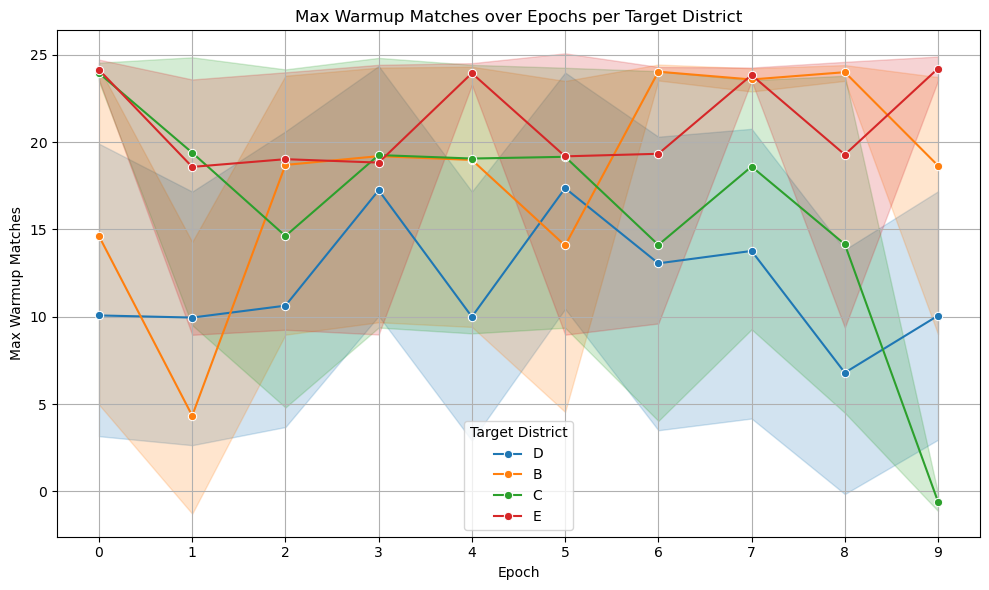

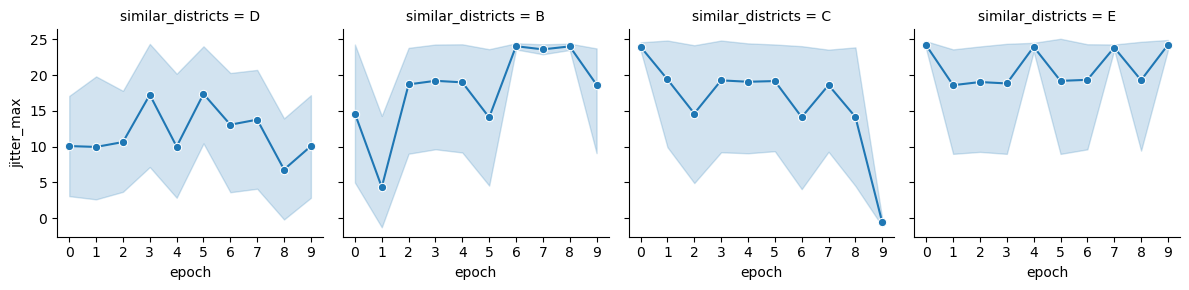

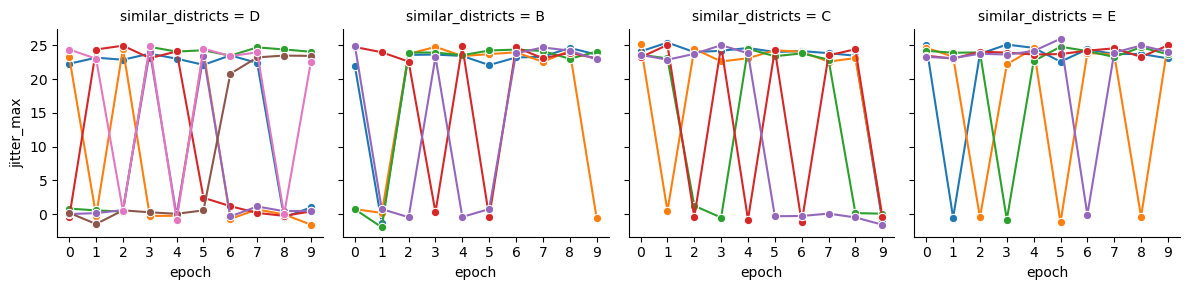

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df_plot = epochs_results[epochs_results['experiment'].isin(best_results['experiment'])].copy()
df_plot['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot))]
df_plot['jitter_max'] = df_plot['max_final_matches'] + df_plot['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

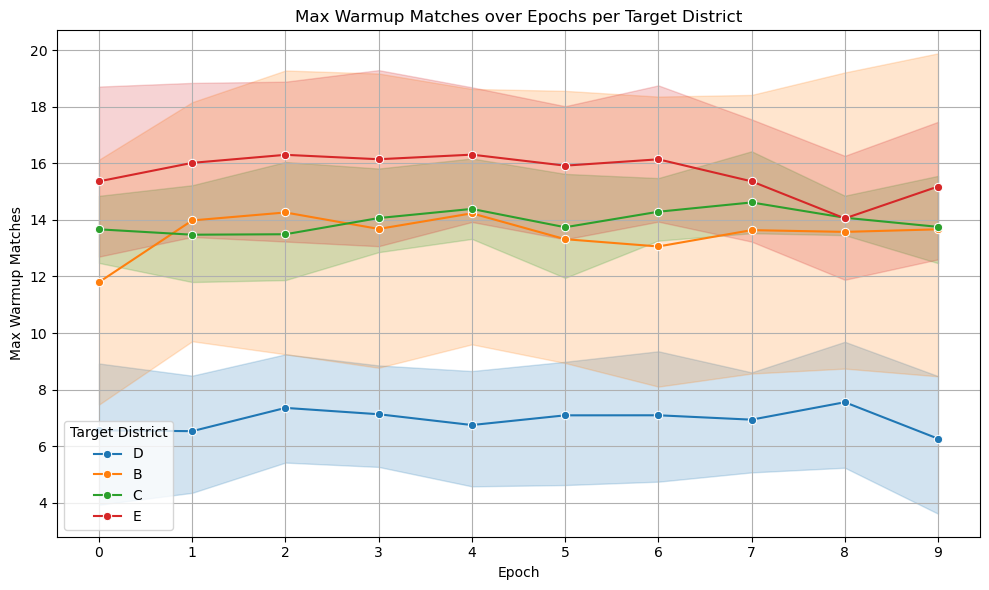

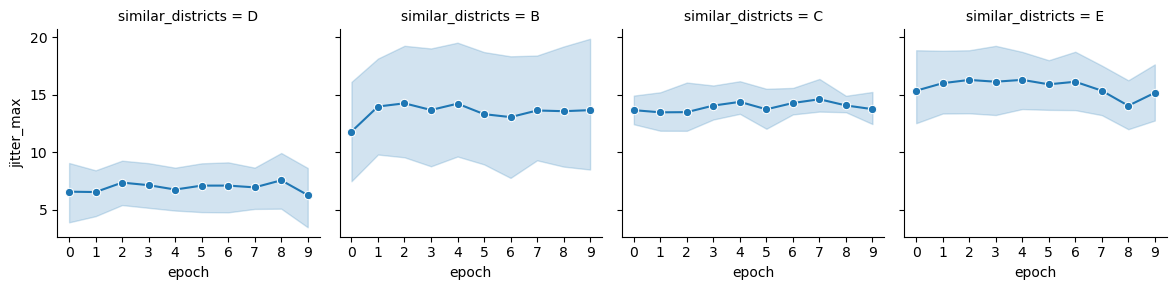

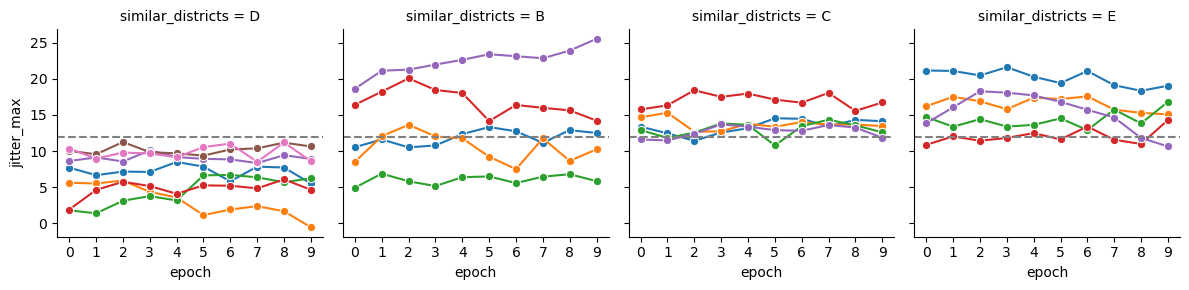

In [16]:
epochs_results_window_cosine, best_results_window_cosine = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['cosine'])

df_plot_window_cosine = epochs_results_window_cosine[epochs_results_window_cosine['experiment'].isin(best_results_window_cosine['experiment'])].copy()
df_plot_window_cosine['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_cosine))]
df_plot_window_cosine['jitter_max'] = df_plot_window_cosine['max_final_matches'] + df_plot_window_cosine['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_cosine,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

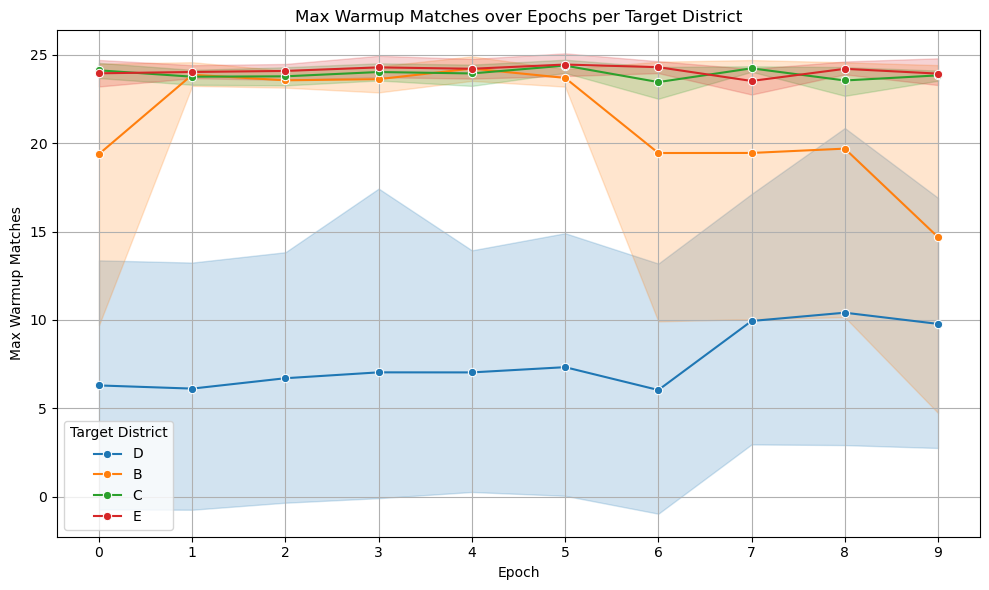

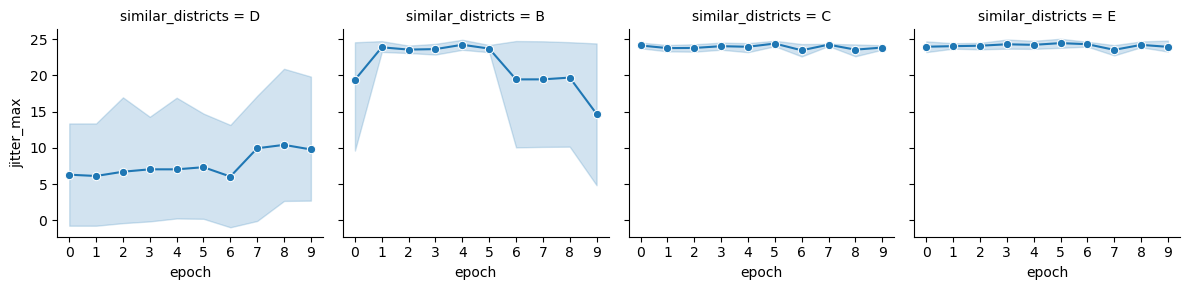

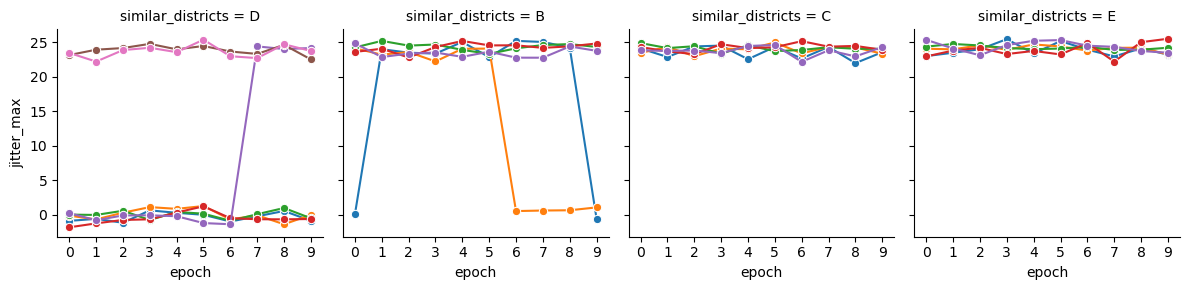

In [18]:
epochs_results_window_dft, best_results_window_dft = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['dft'])

df_plot_window_dft = epochs_results_window_dft[epochs_results_window_dft['experiment'].isin(best_results_window_dft['experiment'])].copy()
df_plot_window_dft['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_dft))]
df_plot_window_dft['jitter_max'] = df_plot_window_dft['max_final_matches'] + df_plot_window_dft['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_dft,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

In [132]:
df_dft = epochs_results_window_dft[epochs_results_window_dft['total_final_matches'] > 20].copy()
df_dft_agg = df_dft.groupby(['experiment', 'exp_id', 'similar_districts']).agg({'correct_epochs' : 'count'}).reset_index()
df_dft_agg[['window', 'step', 'interval']] = df_dft_agg['exp_id'].str.split('__').str[0].str.split('_', expand = True).astype(int)

df_dft_agg['step_ratio'] = df_dft_agg['step'] / df_dft_agg['window']

df_dft_agg_filter = df_dft_agg[df_dft_agg['correct_epochs'] >= 7].drop(columns = ['experiment'])


df_dft_agg_filter

,exp_id,similar_districts,correct_epochs,window,step,interval,step_ratio
1,12_6_7200__0,B,8,12,6,7200,0.500000
10,3_2_43200__0,B,10,3,2,43200,0.666667
11,12_3_43200__0,C,10,12,3,43200,0.250000
12,12_6_43200__0,C,10,12,6,43200,0.500000
13,12_9_43200__0,C,10,12,9,43200,0.750000
...,...,...,...,...,...,...,...
207,3_2_14400__0,B,9,3,2,14400,0.666667
208,6_3_14400__0,B,10,6,3,14400,0.500000
209,9_6_14400__0,B,10,9,6,14400,0.666667
210,12_3_21600__0,D,9,12,3,21600,0.250000


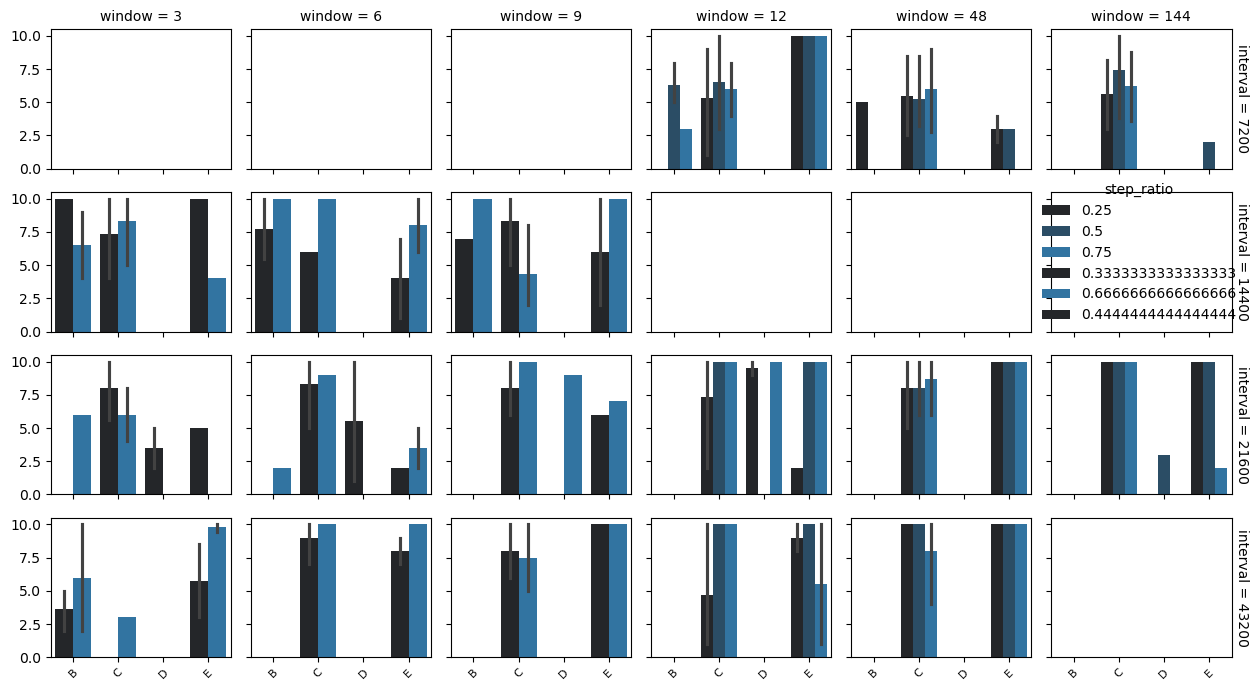

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define FacetGrid with tighter spacing
g = sns.FacetGrid(
    df_dft_agg,
    col=col_var,
    row=row_var,
    col_order=df_dft_agg[col_var].sort_values().unique(),
    row_order=df_dft_agg[row_var].sort_values().unique(),
    margin_titles=True,        # Helps use space better
    despine=False,             # Keeps axes for reference
    height=1.75,                # Smaller subplot height
    aspect=1                   # Adjust aspect ratio (width / height)
)

# Map barplot with narrower bars
g.map_dataframe(
    sns.barplot,
    x='similar_districts',
    y='correct_epochs',
    order=df_dft_agg['similar_districts'].sort_values().unique(),
    hue=hue_var,
    hue_order=df_dft_agg[hue_var].sort_values().unique(),
    width=.8,                
    # palette='Dark2'
)

# Reduce spacing between subplots
g.fig.subplots_adjust(
    hspace=0.2,  # vertical space between rows
    wspace=0.05  # horizontal space between columns
)

# Reduce legend size and move to a compact position
g.add_legend(title=hue_var)
g._legend.set_bbox_to_anchor((.995, 0.625))  # move legend to side
g._legend.set_frame_on(False)

# Optional: Rotate x-ticks and tighten layout
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)
    ax.set_ylabel('')
    ax.set_xlabel('')

plt.tight_layout()


In [180]:
python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 

python Run_Experiment.py --experiment_id A_62_LL_ML__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_36_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 36 


python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 

python Run_Experiment.py --experiment_id A_62_LL_ML__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_72_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 72 


python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LM__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LM_LH_LL_LL --extra_coments NEW_WINDOW_LL_LM_LH_LL_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LM_LL_LL --extra_coments NEW_WINDOW_LL_LH_LM_LL_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LM_LH --extra_coments NEW_WINDOW_LL_LL_LL_LM_LH__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LL_LH_LM --extra_coments NEW_WINDOW_LL_LL_LL_LH_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_LL_LL_LM --extra_coments NEW_WINDOW_LL_LH_LL_LL_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LM_LH_LL --extra_coments NEW_WINDOW_LL_LL_LM_LH_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LL_LH_LM_LL --extra_coments NEW_WINDOW_LL_LL_LH_LM_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_LH__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 

python Run_Experiment.py --experiment_id A_62_LL_ML__LL_HL_ML_LH_LL --extra_coments NEW_WINDOW_LL_HL_ML_LH_LL__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_LH_HM_MH_ML --extra_coments NEW_WINDOW_LL_LH_HM_MH_ML__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_MM_HL_ML_LM --extra_coments NEW_WINDOW_LL_MM_HL_ML_LM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 


python Run_Experiment.py --experiment_id A_62_LL_ML__LL_ML_HL_LM_HM --extra_coments NEW_WINDOW_LL_ML_HL_LM_HM__144_108_43200___0 --seed 0 --communication_epoch 10 --local_epoch 1 --interval_agg 43200 --window_size 144 --step_size 108 


array(['12_3_43200__0', '12_6_43200__0', '12_9_43200__0', '3_1_43200__0',
       '3_2_43200__0', '48_12_43200__0', '48_24_43200__0',
       '48_36_43200__0', '6_3_43200__0', '6_4_43200__0', '9_4_43200__0',
       '9_6_43200__0', '12_3_7200__0', '12_6_7200__0', '12_9_7200__0',
       '144_108_7200__0', '144_36_7200__0', '144_72_7200__0',
       '48_12_7200__0', '48_24_7200__0', '48_36_7200__0', '3_1_14400__0',
       '3_2_14400__0', '6_3_14400__0', '6_4_14400__0', '9_4_14400__0',
       '9_6_14400__0', '12_3_21600__0', '12_6_21600__0', '12_9_21600__0',
       '144_108_21600__0', '144_36_21600__0', '144_72_21600__0',
       '3_1_21600__0', '3_2_21600__0', '48_12_21600__0', '48_24_21600__0',
       '48_36_21600__0', '6_3_21600__0', '6_4_21600__0', '9_4_21600__0',
       '9_6_21600__0'], dtype=object)

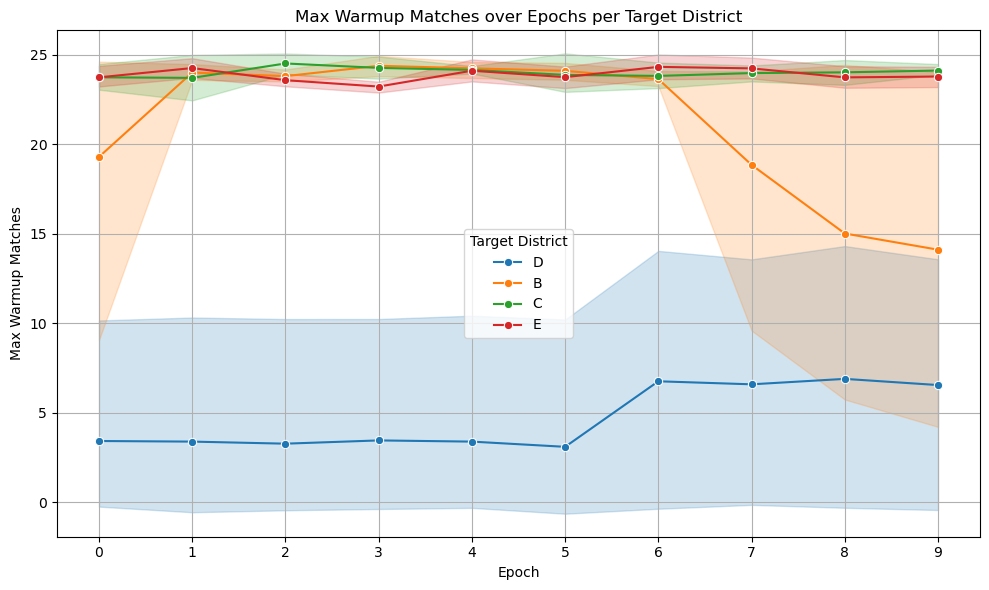

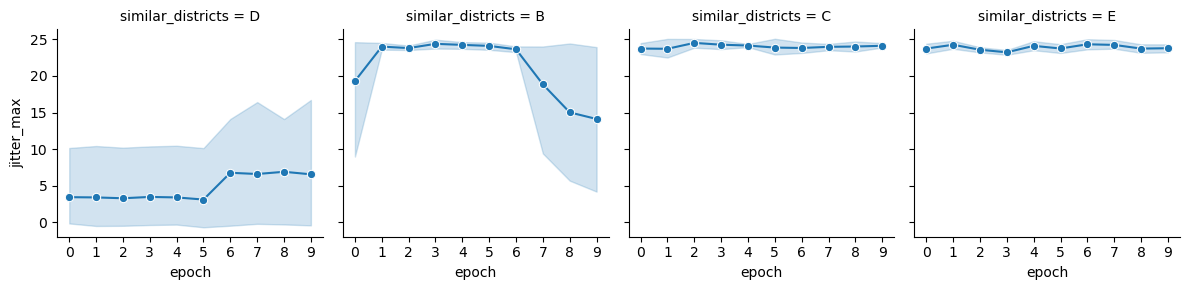

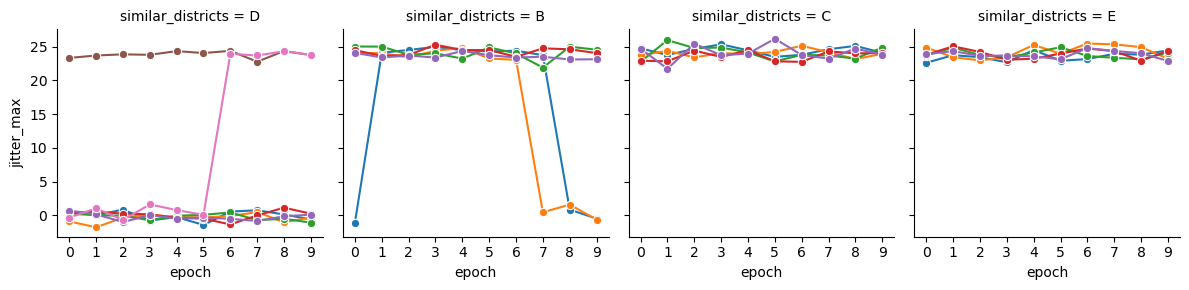

In [82]:
epochs_results_window_wavelet, best_results_window_wavelet = compute_results(experiment_id = 'NEW_WINDOW', metrics = ['wavelet'])

df_plot_window_wavelet = epochs_results_window_wavelet[epochs_results_window_wavelet['experiment'].isin(best_results_window_wavelet['experiment'])].copy()
df_plot_window_wavelet['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_window_wavelet))]
df_plot_window_wavelet['jitter_max'] = df_plot_window_wavelet['max_final_matches'] + df_plot_window_wavelet['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_window_wavelet,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_window_wavelet, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_window_wavelet, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

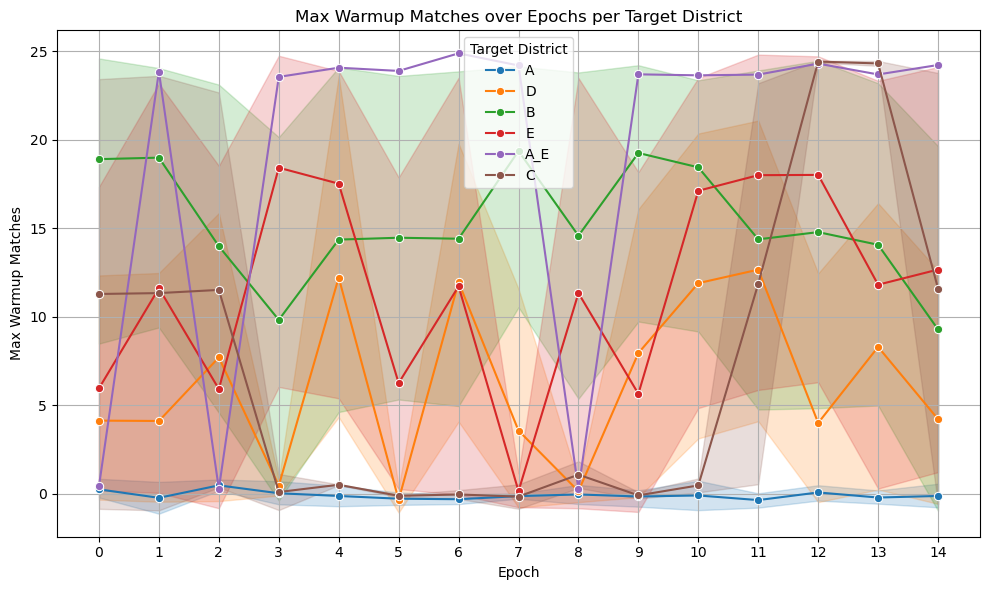

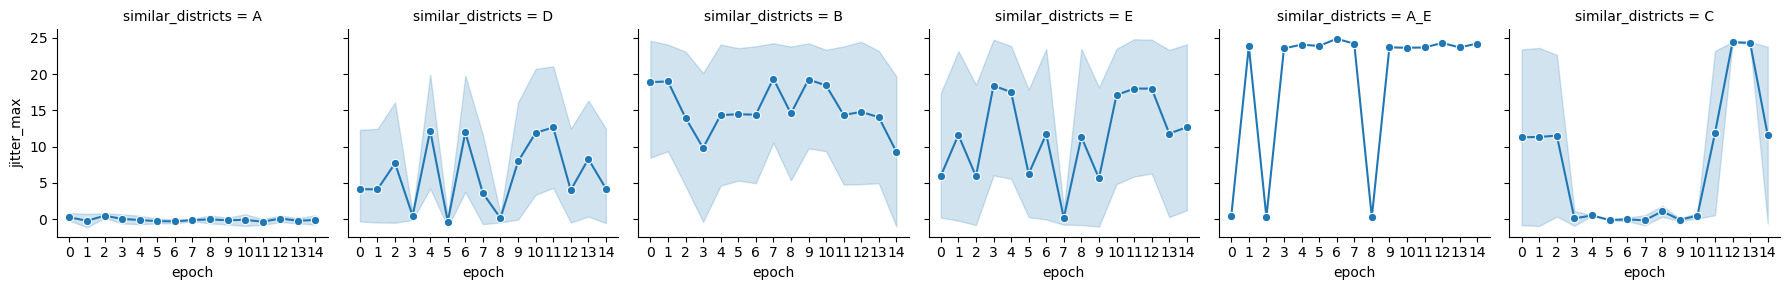

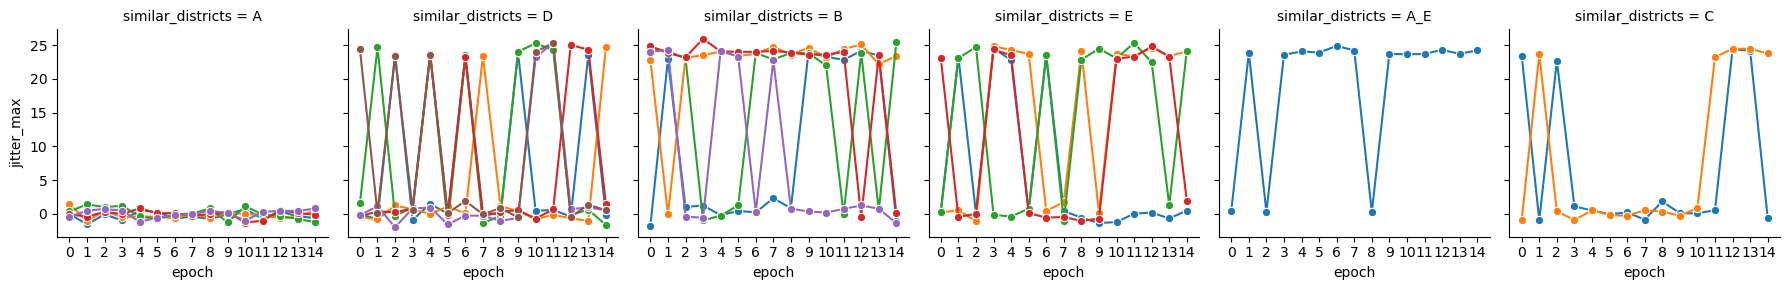

In [114]:
epochs_results_testing, best_results_testing = compute_results(experiment_id = 'NEW_TESTING', metrics = ['autocorr'])

df_plot_testing = epochs_results_testing[epochs_results_testing['experiment'].isin(best_results_testing['experiment'])].copy()
df_plot_testing['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing))]
df_plot_testing['jitter_max'] = df_plot_testing['max_final_matches'] + df_plot_testing['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

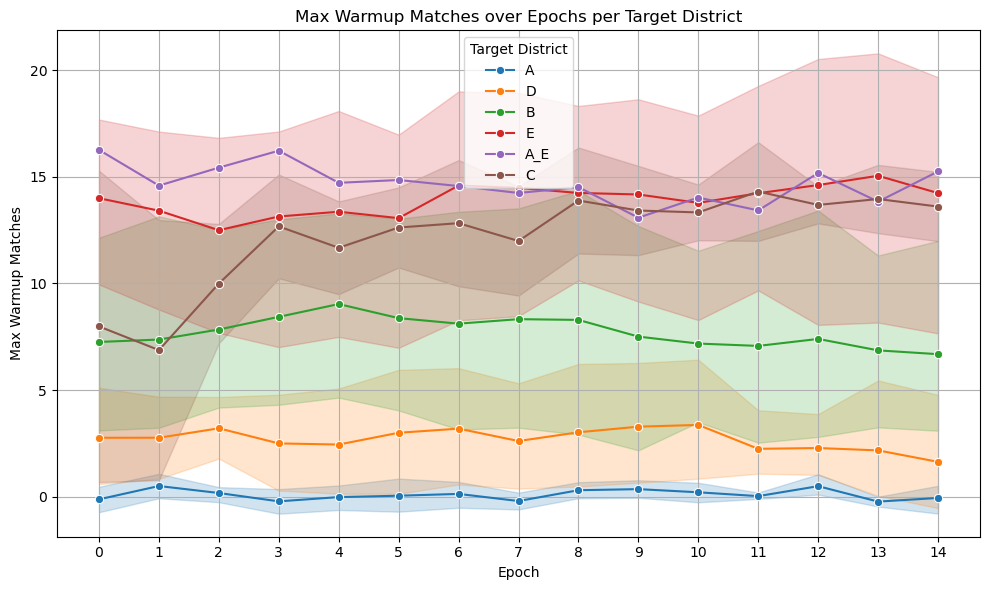

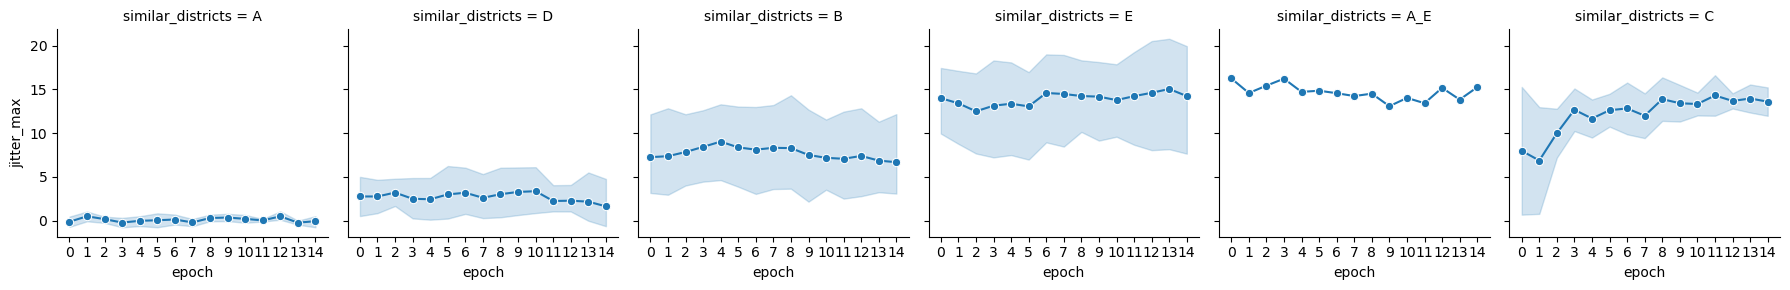

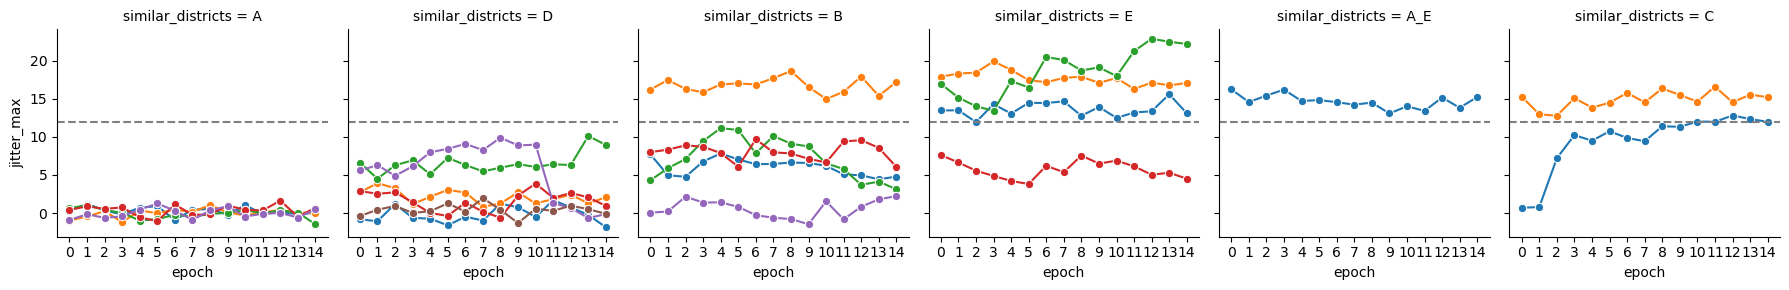

In [122]:
epochs_results_testing_cosine, best_results_testing_cosine = compute_results(experiment_id = 'NEW_TESTING', metrics = ['cosine'])

df_plot_testing_cosine = epochs_results_testing_cosine[epochs_results_testing_cosine['experiment'].isin(best_results_testing_cosine['experiment'])].copy()
df_plot_testing_cosine['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing_cosine))]
df_plot_testing_cosine['jitter_max'] = df_plot_testing_cosine['max_final_matches'] + df_plot_testing_cosine['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing_cosine,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing_cosine, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )
g.refline(y=12)

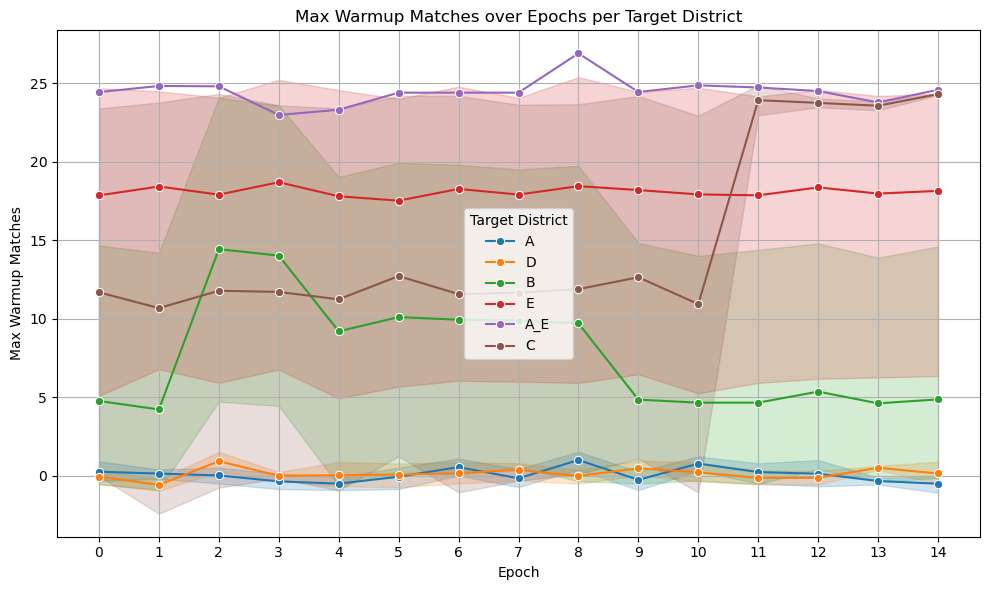

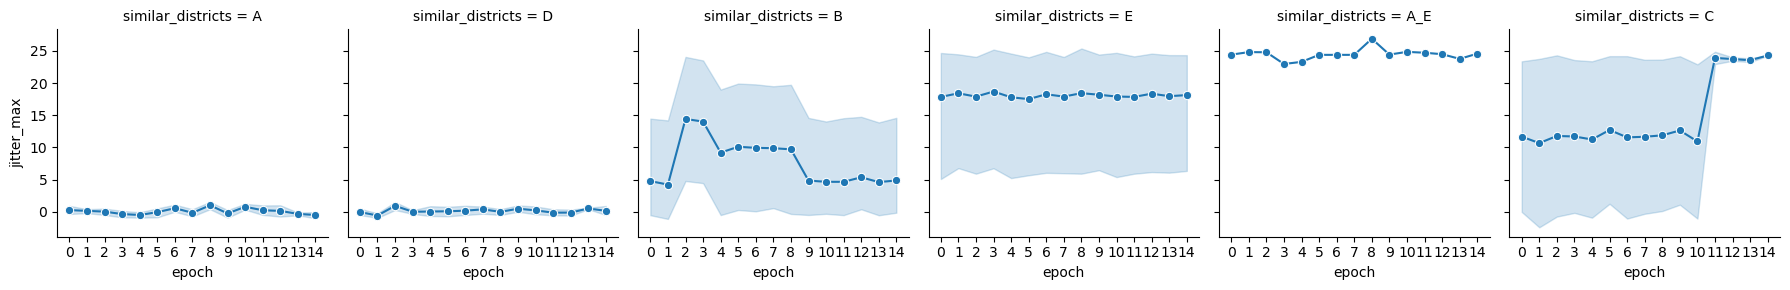

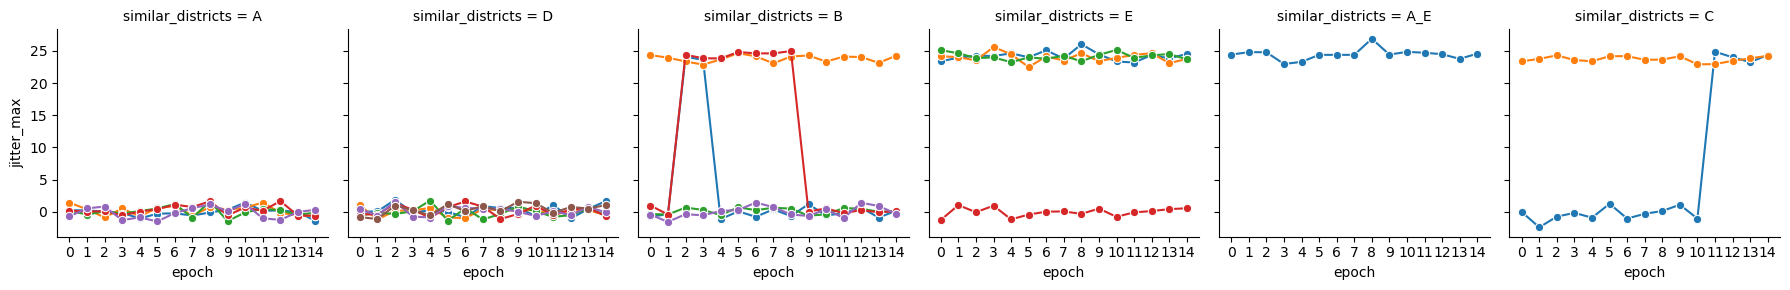

In [106]:
epochs_results_testing_dft, best_results_testing_dft = compute_results(experiment_id = 'NEW_TESTING', metrics = ['dft'])

df_plot_testing_dft = epochs_results_testing_dft[epochs_results_testing_dft['experiment'].isin(best_results_testing_dft['experiment'])].copy()
df_plot_testing_dft['aux'] = [np.random.normal(loc=0, scale=.75) for _ in range (len(df_plot_testing_dft))]
df_plot_testing_dft['jitter_max'] = df_plot_testing_dft['max_final_matches'] + df_plot_testing_dft['aux'] 

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot_testing_dft,
    x='epoch',
    y='jitter_max',
    hue='similar_districts',
    marker='o'
)
plt.title('Max Warmup Matches over Epochs per Target District')
plt.xlabel('Epoch')
plt.ylabel('Max Warmup Matches')
plt.legend(title='Target District')
plt.grid(True)
plt.tight_layout()
plt.show()

g = sns.FacetGrid(df_plot_testing_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o'
            )

display(g)

g = sns.FacetGrid(df_plot_testing_dft, col = 'similar_districts')
g.map_dataframe(sns.lineplot,
                x='epoch',
                y='jitter_max',
                marker='o',
                hue = 'experiment'
            )

In [61]:
def get_similar_districts_from_path(path_string):
    try:
        # Split the experiment name
        parts = path_string.split('__')
        
        # Get target info
        header = parts[0]  # e.g., 'E_15_LL_LM'
        target_district = header.split('_')[0]  # 'E'
        target_init_state = header.split('_')[2]  # 'LL'
        target_final_state = header.split('_')[3]  # 'LM'

        # Get district state mapping
        state_mapping_str = parts[1]  # e.g., 'LM_LL_LM_LL_LL'
        district_states = state_mapping_str.split('_')

        # Districts in order
        district_names = ['A', 'B', 'C', 'D', 'E']

        if len(district_states) < 5:
            raise ValueError("Expected at least 5 states for districts A–E. Got: " + str(district_states))

        # Map district to state
        district_state_map = dict(zip(district_names, district_states[:5]))

        # Find similar districts (excluding the target itself)
        similar_initial = [d for d, s in district_state_map.items() if s == target_init_state and d != target_district]
        similar_final = [d for d, s in district_state_map.items() if s == target_final_state and d != target_district]

        return {
            "target_district": target_district,
            "target_init_state": target_init_state,
            "target_final_state": target_final_state,
            "initial_similar_districts": similar_initial,
            "final_similar_districts": similar_final
        }

    except Exception as e:
        print(f"Error parsing: {e}")
        return None


def analyze_experiment(results_id, results_path='results'):
    try:
        info_state = get_similar_districts_from_path(results_id)
        tgt_client = results_id[0]
        path = f"{results_path}/{results_id}/Baseline_proto.parquet"

        results_proto = pd.read_parquet(path)
        results_tgt = results_proto[results_proto['client_1'].str.contains(f'_{tgt_client}_')].drop(columns=['client_1'])

        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['cosine'].rank(method='dense', ascending=True)

        # remover!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        results_tgt['test_metric'] = results_tgt['cosine'] + results_tgt['autocorr']
        results_tgt['cosine_rank'] = results_tgt.groupby(['epoch', 'label'])['test_metric'].rank(method='dense', ascending=True)


        top_ranked = results_tgt[results_tgt['cosine_rank'] == 1]

        summary = top_ranked.groupby(['epoch', 'label', 'client_2']).size().reset_index(name='count')
        summary['district_letter'] = summary['client_2'].str.extract(r'District_([A-Z])')

        summary['epoch'] = pd.to_numeric(summary['epoch'], errors='coerce')
        summary['label'] = pd.to_numeric(summary['label'], errors='coerce')
        summary = summary.dropna(subset=['district_letter', 'epoch', 'label'])

        # Final-only match
        summary['match_final_only'] = summary['district_letter'].isin(info_state['final_similar_districts'])

        # Warm-up rule
        def match_with_warmup(row):
            if row['label'] < 3:
                return row['district_letter'] in info_state['initial_similar_districts']
            else:
                return row['district_letter'] in info_state['final_similar_districts']

        summary['match_warmup_rule'] = summary.apply(match_with_warmup, axis=1)

        # Summarize results
        total_final = summary['match_final_only'].sum()
        total_warmup = summary['match_warmup_rule'].sum()

        matches_per_epoch = summary.groupby('epoch')[['match_final_only', 'match_warmup_rule']].sum().reset_index()
        max_final = matches_per_epoch['match_final_only'].max()
        max_warmup = matches_per_epoch['match_warmup_rule'].max()

        matches_per_epoch['experiment'] = results_id
        matches_per_epoch['max_final_matches'] = max_final
        matches_per_epoch['max_warmup_matches'] = max_warmup

        # return matches_per_epoch

        return {
            'experiment': results_id,
            'total_final_matches': total_final,
            'total_warmup_matches': total_warmup,
            'max_final_matches': max_final,
            'max_warmup_matches': max_warmup
        }

    except Exception as e:
        return {'experiment': results_id, 'error': str(e)}


In [69]:
CASE_TGT = 'NEW_WINDOW'

In [75]:
import pandas as pd
import os
import glob
from collections import defaultdict

results_path = 'results'

# Get all folder paths
folders_with_rep = [f for f in glob.glob(os.path.join(results_path, F'*{CASE_TGT}*')) if os.path.isdir(f)]

# Group by base experiment (strip off last suffix)
grouped_exps = defaultdict(list)
for path in folders_with_rep:
    folder_name = os.path.basename(path)
    if '__' in folder_name:
        base = '__'.join(folder_name.split('__')[:-1])
        grouped_exps[base].append(path)
    else:
        grouped_exps[folder_name].append(path)

# Run analysis for each experiment folder
all_results = []
for base_name, group_paths in grouped_exps.items():
    for path in group_paths:
        exp_name = os.path.basename(path)
        result = analyze_experiment(exp_name, results_path=results_path)
        all_results.append(result)


df_results = pd.DataFrame(all_results)

def extract_exp_info(exp_id):
    try:
        parts = exp_id.split('__')
        target_header = parts[0]                     # 'E_15_LL_LM'
        mapping = parts[1]                           # 'LM_LL_LM_LL_LL'

        target_district = target_header.split('_')[0]     # 'E'
        node_id = target_header.split('_')[1]             # '15'
        init_state = target_header.split('_')[2]          # 'LL'
        final_state = target_header.split('_')[3]         # 'LM'

        aux_exp1 = exp_id.split('__')[-1]
        aux_exp2 = exp_id.split('__')[-2]

        return pd.Series([
            f"{target_district}_{node_id}",         # 'E_15'
            f"{init_state}_{final_state}",          # 'LL_LM'
            mapping[:14],                                 # 'LM_LL_LM_LL_LL'
            f"{aux_exp2}_{aux_exp1}"
        ])
    except Exception as e:
        print(f"Failed parsing exp_id: {exp_id} — {e}")
        return pd.Series([None, None, None])

df_results[['target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']] = (
    df_results['experiment'].apply(extract_exp_info)
)


# Get max warmup match for each unique config
idx = df_results.groupby(
    ['target_district_node', 'target_init_final_state', 'initial_state_mapping']
)['total_final_matches'].idxmax()

df_best_per_config = df_results.loc[idx].reset_index(drop=True)

# Optional: sort by warmup performance
df_best_per_config = df_best_per_config.sort_values(by='total_final_matches', ascending=False)

df_best_per_config['correct_epochs'] = df_best_per_config['total_final_matches'] / 24
df_best_per_config['target_district'] = df_best_per_config['target_district_node'].str.split('_').str[0]
df_best_per_config['target_final_state'] = df_best_per_config['target_init_final_state'].str.split('_').str[-1]

df_best_per_config[['A', 'B', 'C', 'D', 'E']] = df_best_per_config['initial_state_mapping'].str.split('_', expand = True)

df_best_per_config.drop(columns = ['target_district_node', 'initial_state_mapping', 'target_init_final_state'], inplace = True)

def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['target_final_state']]
    return '_'.join(match_cols)

df_best_per_config['similar_districts'] = df_best_per_config.apply(find_similar, axis=1)

# Show results
print("🏆 Best experiment per configuration (based on warm-up matches):")
# df_best_per_config[['experiment', 'total_final_matches', 'target_district_node', 'target_init_final_state', 'initial_state_mapping', 'exp_id']]
df_best_per_config[df_best_per_config['similar_districts'] != '']

🏆 Best experiment per configuration (based on warm-up matches):


,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,exp_id,correct_epochs,target_district,target_final_state,A,B,C,D,E,similar_districts
21,A_62_LL_LM__LL_MM_HL_ML_LM_10_1_4_3_NEW_WINDOW...,238,209,24,21,3_1_14400__0,9.916667,A,LM,LL,MM,HL,ML,LM,E
19,A_62_LL_LM__LL_LM_LH_LL_LL_10_1_6_3_NEW_WINDOW...,220,196,24,21,3_2_21600__0,9.166667,A,LM,LL,LM,LH,LL,LL,B
6,A_62_LL_LH__LL_LL_LL_LM_LH_10_1_12_6_NEW_WINDO...,214,192,24,21,6_4_43200__0,8.916667,A,LH,LL,LL,LL,LM,LH,E
1,A_62_LL_LH__LL_LH_HM_MH_ML_10_1_4_6_NEW_WINDOW...,192,170,24,21,6_3_14400__0,8.000000,A,LH,LL,LH,HM,MH,ML,B
23,A_62_LL_ML__LL_LH_HM_MH_ML_10_1_12_9_NEW_WINDO...,189,166,24,21,9_4_43200__0,7.875000,A,ML,LL,LH,HM,MH,ML,E
4,A_62_LL_LH__LL_LL_LH_LM_LL_10_1_4_9_NEW_WINDOW...,182,166,24,21,9_4_14400__0,7.583333,A,LH,LL,LL,LH,LM,LL,C
2,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_6_3_NEW_WINDOW...,161,149,24,21,3_2_21600__0,6.708333,A,LH,LL,LH,LL,LL,LM,B
3,A_62_LL_LH__LL_LH_LM_LL_LL_10_1_6_9_NEW_WINDOW...,159,141,24,21,9_6_21600__0,6.625000,A,LH,LL,LH,LM,LL,LL,B
14,A_62_LL_LM__LL_LH_LM_LL_LL_10_1_6_9_NEW_WINDOW...,157,133,24,21,9_4_21600__0,6.541667,A,LM,LL,LH,LM,LL,LL,C
7,A_62_LL_LH__LL_LL_LM_LH_LL_10_1_4_3_NEW_WINDOW...,152,142,24,21,3_1_14400__0,6.333333,A,LH,LL,LL,LM,LH,LL,D


In [27]:
import warnings
from argparse import ArgumentParser

import pandas as pd

from datasets import Priv_NAMES as DATASET_NAMES
from datasets import get_private_dataset
from models import get_all_models
from models import get_model
from utils.Server import train
from utils.Toolbox_analysis import create_latent_df, process_latent_df

warnings.simplefilter(action='ignore', category=FutureWarning)


def parse_args():
    parser = ArgumentParser(description='You Only Need Me', allow_abbrev=False)
    parser.add_argument('--device_id', type=int, default=0, help='The Device Id for Experiment')
    parser.add_argument('--communication_epoch', type=int, default=10,
                        help='The Communication Epoch in Federated Learning')
    parser.add_argument('--local_epoch', type=int, default=3,
                        help='The Local Epoch for each Participant')

    parser.add_argument('--experiment_id', type=str,
                        default='A_62_LL_LM__LL_LM_LH_LL_LL', help='Experiment identifier')
    parser.add_argument('--extra_coments', type=str,
                        default='NEW_TESTING_LL_HM_LM_MM_LL__24_6___0', help='Aditional info')

    # Data parameter
    parser.add_argument('--dataset', type=str, default='fl_leaks', choices=DATASET_NAMES,
                        help='Which scenario to perform experiments on.')
    parser.add_argument('--domains', type=dict, default={'Graeme': 5}, # TODO REFACTOR TYPE
                        help='Domains and respective number of participants.')

    ## Time series preprocessing
    parser.add_argument('--interval_agg', type=int, default=4 * 60 ** 2,
                        help='Agregation interval (seconds) of time series')
    parser.add_argument('--window_size', type=int, default=1,
                        help='Rolling window length')
    parser.add_argument('--step_size', type=int, default=1,
                        help='Rolling window step size')

    # Model (AER) parameters
    parser.add_argument('--input_size', type=int, default=5,
                        help='Number of sensors')  # TODO adaptar
    parser.add_argument('--output_size', type=int, default=5,
                        help='Shape output - dense layer')
    parser.add_argument('--lstm_units', type=int, default=30,
                        help='Number of LSTM units (the latent space will have dimension 2 times bigger')

    # Participants info
    parser.add_argument('--parti_num', type=int, default=None,
                        help='The Number for Participants. If "None" will be setted as the sum of values described in --domain')
    parser.add_argument('--online_ratio', type=float, default=1,
                        help='The Ratio for Online Clients')

    # Federated parameters
    parser.add_argument('--model', type=str, default='fpl',
                        help='Federated Model name.', choices=get_all_models()) #fedavg
    parser.add_argument('--structure', type=str, default='homogeneity')
    parser.add_argument('--pri_aug', type=str, default='weak',  # weak strong
                        help='Augmentation for Private Data')
    parser.add_argument('--learning_decay', type=bool, default=False,
                        help='The Option for Learning Rate Decay')
    parser.add_argument('--averaging', type=str, default='weight',
                        help='The Option for averaging strategy')

    parser.add_argument('--infoNCET', type=float, default=0.02,
                        help='The InfoNCE temperature')
    parser.add_argument('--T', type=float, default=0.05,
                        help='The Knowledge distillation temperature')
    parser.add_argument('--weight', type=int, default=1,
                        help='The Weigth for the distillation loss')


        # Time variables
    parser.add_argument('--n_segments', type=int, default=12,
                        help='Number of urban growth simulation segments.')
    parser.add_argument('--epochs_lenght', type=int, default=6,
                        help='Number of epochs per simulation run.')
    parser.add_argument('--days_lenght', type=int, default=5,
                        help='Number of days in each epoch.')
    parser.add_argument('--n_intervals', type=int, default=24,
                        help='Number of time intervals per day.')

    # Hydraulic variables
    parser.add_argument('--unit', type=str, default='l/s',
                        help='Measurement unit for flow.')
    parser.add_argument('--leak_severity', type=float, default=0.15,
                        help='Leak severity multiplier.')

    args, unknown = parser.parse_known_args()

    if args.parti_num is None:
        args.parti_num = sum(args.domains.values())
    #
    # best = best_args[args.dataset][args.model]
    #
    # for key, value in best.items():
    #     setattr(args, key, value)
    #
    # if args.seed is not None:
    #     set_random_seed(args.seed)

    return args

In [160]:
import pandas as pd
import numpy as np
from numpy import ndarray

import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter

def get_majority_month_label(windows_timestamps, threshold=0.7):
    """
    Assign continuous month labels (e.g., Jan Year 0 = 0, Jan Year 1 = 12)
    based on majority in each window.

    Parameters:
        windows_timestamps: array-like of shape (num_windows, window_size)
        threshold: float - required fraction of timestamps in one month

    Returns:
        labels: list of int (continuous month indices) or None if threshold not met
        mask: numpy array of bool, True where threshold met
    """
    labels = []
    mask = []

    # Flatten all timestamps to find the earliest year
    all_timestamps = np.concatenate(windows_timestamps)
    all_datetimes = pd.to_datetime(all_timestamps, unit='s')
    base_year = all_datetimes.min().year

    for window in windows_timestamps:
        dt_index = pd.to_datetime(window, unit='s')
        months = dt_index.month
        years = dt_index.year
        # Continuous month index
        continuous_months = (years - base_year) * 12 + (months - 1)

        counts = Counter(continuous_months)
        majority_month, majority_count = counts.most_common(1)[0]
        fraction = majority_count / len(window)

        if fraction >= threshold:
            labels.append(majority_month)
            mask.append(True)
        else:
            labels.append(None)
            mask.append(False)

    return labels, np.array(mask)
    
def prepare_data(args, X: np.ndarray, X_index: np.ndarray, y: np.ndarray = None):
    """
    Prepares PyTorch DataLoader from input data, including hour-based label.
    """


    # # Extract 12-hour format label from timestamps
    # timestamps = pd.to_datetime(X_index, unit='s')
    # # hour = timestamps.hour
    # # label = hour.where(hour < 12, hour - 12).to_numpy()
    # # label = label / args.agg_interval
    # month = timestamps.month - 1
    # label = month.to_numpy()
    # label_tensor = torch.tensor(label, dtype=torch.int64)  # or float32 if needed

    labels, mask = get_majority_month_label(windows_timestamps=X_index, threshold=0.75)
    print("mask shape:", mask.shape)
    print(labels)
    print(mask)
    label_filtered = [l for l in labels if l is not None]
    label_tensor = torch.tensor(label_filtered, dtype=torch.int64)

    X_filtered = X[mask].copy()

    if y is None:
        y = X_filtered.copy()

    # Prepare input and targets
    X_filtered = X[mask].copy()

    if X_filtered.shape[1] < 3:
        raise ValueError(f"Window size too small after filtering: {X_filtered.shape[1]} (need at least 3)")

    # Optionally adjust the slicing if necessary
    X_filtered = X_filtered[:, 1:-1, :]

    ry, y, fy = y[:, 0], y[:, 1:-1], y[:, -1]

    X_tensor = torch.tensor(X_filtered, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    ry_tensor = torch.tensor(ry, dtype=torch.float32).unsqueeze(-1)
    fy_tensor = torch.tensor(fy, dtype=torch.float32).unsqueeze(-1)

    # Add label tensor to dataset
    dataset = torch.utils.data.TensorDataset(X_tensor, ry_tensor, y_tensor, fy_tensor, label_tensor)

    print("X_tensor shape:", X_tensor.shape)
    print("ry_tensor shape:", ry_tensor.shape)
    print("y_tensor shape:", y_tensor.shape)
    print("fy_tensor shape:", fy_tensor.shape)
    print("label_tensor shape:", label_tensor.shape)


    return dataset
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    return dataloader

In [163]:
args = parse_args()
scenario = 'Baseline'

DLS = []
for window in [144]:
    for step in [0.25 * window, 0.5 * window, 0.75 * window]:
        for interval in [12]:
            # try:
            args.interval_agg = interval * 3600
            args.window_size = window
            args.step_size = int(step)  # step is float; cast to int if needed

            priv_dataset = get_private_dataset(args)
            priv_train_loaders = priv_dataset.get_data_loaders(scenario=scenario)
            
            backbones_list = priv_dataset.get_backbone(
                parti_num=args.parti_num,
                names_list=None,
                n_series=args.input_size
            )

            model = get_model(backbones_list, args, priv_dataset)

            priv_train_loaders = priv_dataset.get_data_loaders(scenario='Baseline')

            loader = priv_train_loaders[0]
            print(f"\nParameters:\tW={window}\tS={int(step)}\tA={interval}")
            print("Loader lengths:", len(loader['X']), len(loader['X'][0]))

            dl = prepare_data(args = args, X = loader['X'], X_index = priv_train_loaders[0]['win_idx'], y = None)
            DLS.append(dl)
            # except Exception as e:
            #     print(f"[ERROR] Failed for window={window}, step={step}, interval={interval}")
            #     print("Error:", e)
            #     continue  # skip to next loop iteration


Parameters:	W=144	S=36	A=12
Loader lengths: 37 144
mask shape: (37,)
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False]
X_tensor shape: torch.Size([0, 142, 5])
ry_tensor shape: torch.Size([0, 5, 1])
y_tensor shape: torch.Size([0, 142, 5])
fy_tensor shape: torch.Size([0, 5, 1])
label_tensor shape: torch.Size([0])

Parameters:	W=144	S=72	A=12
Loader lengths: 19 144
mask shape: (19,)
[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]
[False False False False False False False False False False False False
 False False False False Fal

In [113]:
DLS

In [115]:
for i, ds in enumerate(DLS):
    print(f"Dataset {i} length: {len(ds)}")

Dataset 0 length: 34
Dataset 1 length: 0
Dataset 2 length: 17
Dataset 3 length: 0
Dataset 4 length: 11
Dataset 5 length: 0


In [129]:
loader['X_raw'].shape

(1441, 5)

In [11]:
[t / 3600 for t in loader['X_index'][:10]]

[0.0, 4500.0, 9000.0]

In [136]:
L = 360*2*24
L

17280

In [138]:
g = 12
M = L/ g
M

1440.0

In [153]:
W = 144
S = 108

N = 1 + (M - W) / S
N

13.0

In [175]:
[l/(3600*24*30) for l in loader['X_index']]

[0.0, 1.8, 3.6, 5.4, 7.2, 9.0, 10.8, 12.6, 14.4, 16.2, 18.0, 19.8, 21.6]